In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [3]:
!pip install pandas numpy matplotlib scikit-learn openpyxl

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [6]:
df = pd.read_excel("WA_Fn-UseC_-HR-Employee-Attrition.csv.xlsx")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'WA_Fn-UseC_-HR-Employee-Attrition.csv.xlsx'

In [7]:
!pip install pandas openpyxl

In [1]:
import pandas as pd


df = pd.read_excel("WA_Fn-UseC_-HR-Employee-Attrition.xlsx")


df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'WA_Fn-UseC_-HR-Employee-Attrition.xlsx'

In [9]:
df = pd.read_excel(r"C:\Users\SELMAN\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.xlsx")

In [3]:
import pandas as pd

# To upload the data
df = pd.read_excel(r"C:\Users\SELMAN\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.xlsx")

# To display the first 5 rows of data on the screen
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2


In [2]:

print("Satır - Sütun sayısı:", df.shape)

# Missing data check
print("\nEksik veri sayısı:")
print(df.isnull().sum())

# Target distribution
print("\nAttrition dağılımı:")
print(df["Attrition"].value_counts())

Satır - Sütun sayısı: (1470, 32)

Eksik veri sayısı:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrMana

In [4]:
# The code I wrote to convert the target variable to a 0/1 format.
df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})

# To automatically select categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Kategorik sütunlar:")
print(categorical_cols)

# I converted the categorical columns using one-hot encoding.
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Yeni veri boyutu:", df_encoded.shape)
df_encoded.head()

Kategorik sütunlar:
Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')
Yeni veri boyutu: (1470, 46)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,2,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,5,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,7,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [5]:
from sklearn.model_selection import train_test_split

#So, I performed the data splitting operation before machine learning using these codes.
X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]


X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train dağılımı:")
print(y_train.value_counts())

print("\ny_test dağılımı:")
print(y_test.value_counts())

X_train: (1176, 45)
X_test: (294, 45)
y_train dağılımı:
Attrition
0    986
1    190
Name: count, dtype: int64

y_test dağılımı:
Attrition
0    247
1     47
Name: count, dtype: int64


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# for Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# for train the model
dt_model.fit(X_train, y_train)

# for guess
dt_pred = dt_model.predict(X_test)


print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1-score:", f1_score(y_test, dt_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Results
Accuracy: 0.7959183673469388
Precision: 0.3673469387755102
Recall: 0.3829787234042553
F1-score: 0.375

Confusion Matrix:
[[216  31]
 [ 29  18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       247
           1       0.37      0.38      0.38        47

    accuracy                           0.80       294
   macro avg       0.62      0.63      0.63       294
weighted avg       0.80      0.80      0.80       294



In [7]:
from sklearn.ensemble import RandomForestClassifier

# for Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# for train the model
rf_model.fit(X_train, y_train)

# for guess
rf_pred = rf_model.predict(X_test)

# results
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1-score:", f1_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results
Accuracy: 0.8333333333333334
Precision: 0.4166666666666667
Recall: 0.10638297872340426
F1-score: 0.1694915254237288

Confusion Matrix:
[[240   7]
 [ 42   5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



In [16]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(X_train, y_train)

rf_balanced_pred = rf_balanced.predict(X_test)

print("Balanced Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_balanced_pred))
print("Precision:", precision_score(y_test, rf_balanced_pred))
print("Recall:", recall_score(y_test, rf_balanced_pred))
print("F1-score:", f1_score(y_test, rf_balanced_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_balanced_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_balanced_pred))

Balanced Random Forest Results
Accuracy: 0.8333333333333334
Precision: 0.375
Recall: 0.06382978723404255
F1-score: 0.10909090909090909

Confusion Matrix:
[[242   5]
 [ 44   3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294



In [17]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Balanced Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, rf_balanced_pred)
    ],
    "Precision": [
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, rf_balanced_pred)
    ],
    "Recall": [
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, rf_balanced_pred)
    ],
    "F1-score": [
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, rf_balanced_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.795918,0.367347,0.382979,0.375000
1,Random Forest,0.833333,0.416667,0.106383,0.169492
2,Balanced Random Forest,0.833333,0.375000,0.063830,0.109091


                 Feature  Importance
0                    Age    0.067520
10         MonthlyIncome    0.067323
17     TotalWorkingYears    0.054735
1              DailyRate    0.049621
2       DistanceFromHome    0.044847
6             HourlyRate    0.044293
20        YearsAtCompany    0.043708
11           MonthlyRate    0.043273
4         EmployeeNumber    0.043263
23  YearsWithCurrManager    0.038706


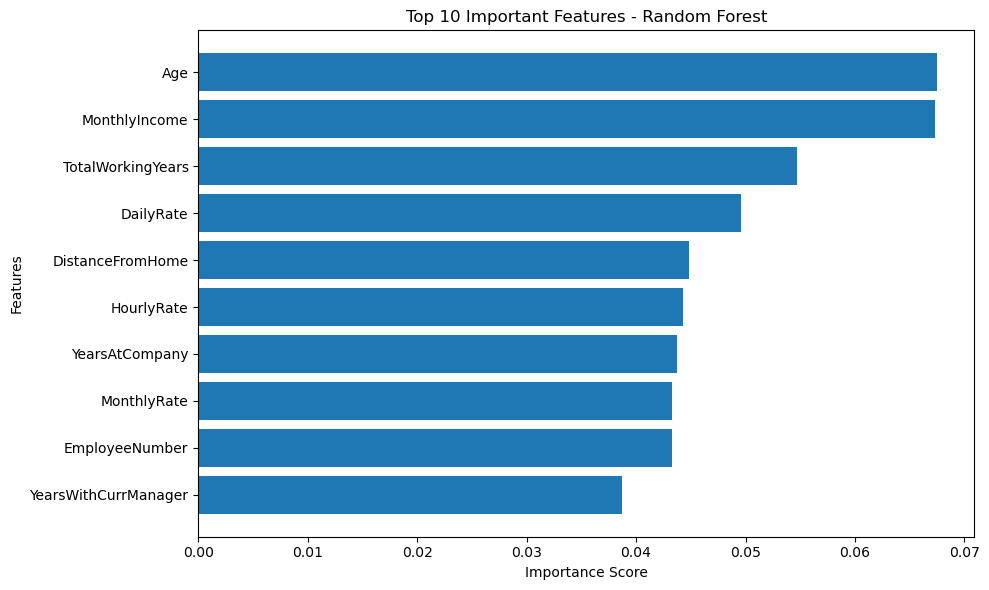

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Random Forest feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
).head(10)

print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")
plt.tight_layout()
plt.show()

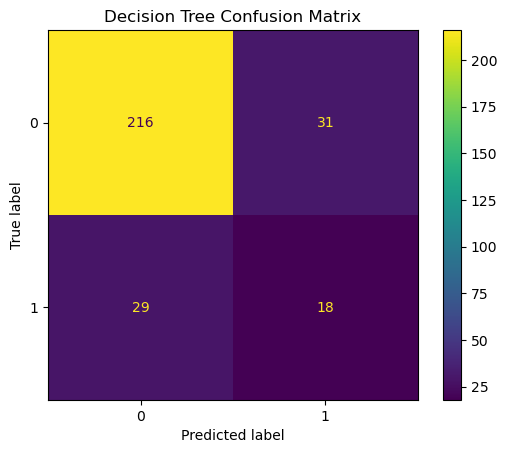

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Decision Tree confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, dt_pred)

plt.title("Decision Tree Confusion Matrix")
plt.show()

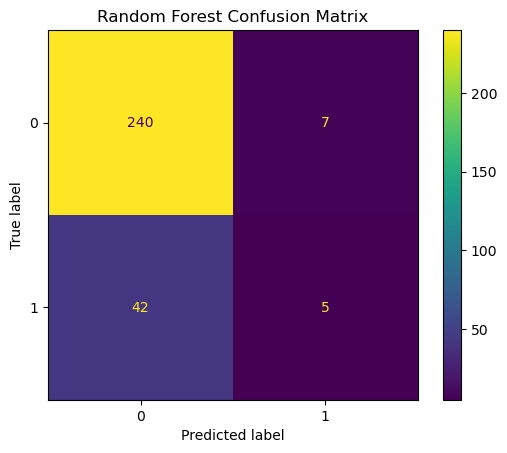

In [20]:
# Random Forest confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

company_df = pd.read_excel(r"C:\Users\SELMAN\Downloads\2025 Personel Verileri Anonim.xlsx")

company_df.head()

,employee_id,Cinsiyet,Yaşı,Toplam Ücret,GÖREVİ,ŞUBE,İŞE GİRİŞ,İŞTEN AYRILIŞ,TOPLAM KIDEM(ÇALIŞMA SÜRESİ),TOPLAM KIDEM (AY),DURUM,ÇIKIŞ NEDENİ,ÇALIŞTIĞI SÜRE YIL,ÇALIŞTIĞI SÜRE AY,ÇALIŞTIĞI SÜRE GÜN,GİRİŞ YIL-AY,AYRILIŞ YIL-AY
0,EMP001,Erkek,20,23160.67,Servis Elemanı (Garson),Branch_05,2025-10-03,NaT,0 yıl 7 ay 15 gün,7,Halen çalışmakta,çalışıyor,0,7,15,2025-10,NaN
1,EMP002,Erkek,23,23160.67,Servis Elemanı (Garson),Branch_05,2025-02-25,2025-03-24,0 yıl 0 ay 27 gün,0,Ayrıldı,Deneme Süresi içinde (4857/15),0,0,27,2025-02,2025-03
2,EMP003,Erkek,18,23160.67,Mutfak Görevlisi,Branch_05,2025-06-25,2025-08-12,0 yıl 1 ay 18 gün,1,Ayrıldı,İstifa (4857/17),0,1,18,2025-06,2025-08
3,EMP004,Kadın,23,23160.67,Servis Elemanı (Garson),Branch_05,2025-10-19,NaT,0 yıl 6 ay 29 gün,6,Halen çalışmakta,çalışıyor,0,6,29,2025-10,NaN
4,EMP005,Erkek,22,23160.67,Mutfak Görevlisi,Branch_05,2025-10-01,2025-10-15,0 yıl 0 ay 14 gün,0,Ayrıldı,İstifa (4857/17),0,0,14,2025-10,2025-10


In [3]:
print("Satır - Sütun sayısı:", company_df.shape)

print("\nKolonlar:")
print(company_df.columns)

print("\nEksik veri sayısı:")
print(company_df.isnull().sum())

print("\nİlk 5 satır:")
display(company_df.head())

Satır - Sütun sayısı: (528, 17)

Kolonlar:
Index(['employee_id', 'Cinsiyet', 'Yaşı', 'Toplam Ücret', 'GÖREVİ', 'ŞUBE',
       'İŞE GİRİŞ', 'İŞTEN AYRILIŞ', 'TOPLAM KIDEM(ÇALIŞMA SÜRESİ)',
       'TOPLAM KIDEM (AY)', 'DURUM', 'ÇIKIŞ NEDENİ', 'ÇALIŞTIĞI SÜRE YIL',
       'ÇALIŞTIĞI SÜRE AY', 'ÇALIŞTIĞI SÜRE GÜN', 'GİRİŞ YIL-AY',
       'AYRILIŞ YIL-AY'],
      dtype='object')

Eksik veri sayısı:
employee_id                       0
Cinsiyet                          0
Yaşı                              0
Toplam Ücret                      0
GÖREVİ                            0
ŞUBE                              0
İŞE GİRİŞ                         0
İŞTEN AYRILIŞ                   134
TOPLAM KIDEM(ÇALIŞMA SÜRESİ)      0
TOPLAM KIDEM (AY)                 0
DURUM                             0
ÇIKIŞ NEDENİ                     10
ÇALIŞTIĞI SÜRE YIL                0
ÇALIŞTIĞI SÜRE AY                 0
ÇALIŞTIĞI SÜRE GÜN                0
GİRİŞ YIL-AY                      0
AYRILIŞ YIL-AY             

,employee_id,Cinsiyet,Yaşı,Toplam Ücret,GÖREVİ,ŞUBE,İŞE GİRİŞ,İŞTEN AYRILIŞ,TOPLAM KIDEM(ÇALIŞMA SÜRESİ),TOPLAM KIDEM (AY),DURUM,ÇIKIŞ NEDENİ,ÇALIŞTIĞI SÜRE YIL,ÇALIŞTIĞI SÜRE AY,ÇALIŞTIĞI SÜRE GÜN,GİRİŞ YIL-AY,AYRILIŞ YIL-AY
0,EMP001,Erkek,20,23160.67,Servis Elemanı (Garson),Branch_05,2025-10-03,NaT,0 yıl 7 ay 15 gün,7,Halen çalışmakta,çalışıyor,0,7,15,2025-10,NaN
1,EMP002,Erkek,23,23160.67,Servis Elemanı (Garson),Branch_05,2025-02-25,2025-03-24,0 yıl 0 ay 27 gün,0,Ayrıldı,Deneme Süresi içinde (4857/15),0,0,27,2025-02,2025-03
2,EMP003,Erkek,18,23160.67,Mutfak Görevlisi,Branch_05,2025-06-25,2025-08-12,0 yıl 1 ay 18 gün,1,Ayrıldı,İstifa (4857/17),0,1,18,2025-06,2025-08
3,EMP004,Kadın,23,23160.67,Servis Elemanı (Garson),Branch_05,2025-10-19,NaT,0 yıl 6 ay 29 gün,6,Halen çalışmakta,çalışıyor,0,6,29,2025-10,NaN
4,EMP005,Erkek,22,23160.67,Mutfak Görevlisi,Branch_05,2025-10-01,2025-10-15,0 yıl 0 ay 14 gün,0,Ayrıldı,İstifa (4857/17),0,0,14,2025-10,2025-10


In [11]:
# I have prepared the dataset to be used for K-Means.
cluster_df = company_df.copy()

# I noticed there were missing exit reasons and I filled them in.
cluster_df["ÇIKIŞ NEDENİ"] = cluster_df["ÇIKIŞ NEDENİ"].fillna("Unknown")

# Columns selected for K-Means
selected_cols = [
    "Yaşı",
    "Toplam Ücret",
    "TOPLAM KIDEM (AY)",
    "ÇALIŞTIĞI SÜRE AY",
    "ÇALIŞTIĞI SÜRE GÜN",
    "DURUM",
    "ŞUBE",
    "GÖREVİ"
]

cluster_data = cluster_df[selected_cols]

print(cluster_data.head())
print("\nEksik veri kontrolü:")
print(cluster_data.isnull().sum())

   Yaşı  Toplam Ücret  TOPLAM KIDEM (AY)  ÇALIŞTIĞI SÜRE AY  \
0    20      23160.67                  7                  7   
1    23      23160.67                  0                  0   
2    18      23160.67                  1                  1   
3    23      23160.67                  6                  6   
4    22      23160.67                  0                  0   

   ÇALIŞTIĞI SÜRE GÜN             DURUM       ŞUBE                   GÖREVİ  
0                  15  Halen çalışmakta  Branch_05  Servis Elemanı (Garson)  
1                  27           Ayrıldı  Branch_05  Servis Elemanı (Garson)  
2                  18           Ayrıldı  Branch_05         Mutfak Görevlisi  
3                  29  Halen çalışmakta  Branch_05  Servis Elemanı (Garson)  
4                  14           Ayrıldı  Branch_05         Mutfak Görevlisi  

Eksik veri kontrolü:
Yaşı                  0
Toplam Ücret          0
TOPLAM KIDEM (AY)     0
ÇALIŞTIĞI SÜRE AY     0
ÇALIŞTIĞI SÜRE GÜN    0
DURUM      

In [12]:
from sklearn.preprocessing import StandardScaler

# I'm one-hot encoding categorical variables.
cluster_encoded = pd.get_dummies(cluster_data, drop_first=True)

print("Encoding sonrası veri boyutu:", cluster_encoded.shape)
cluster_encoded.head()

Encoding sonrası veri boyutu: (528, 33)


,Yaşı,Toplam Ücret,TOPLAM KIDEM (AY),ÇALIŞTIĞI SÜRE AY,ÇALIŞTIĞI SÜRE GÜN,DURUM_Halen çalışmakta,ŞUBE_Branch_01,ŞUBE_Branch_02,ŞUBE_Branch_03,ŞUBE_Branch_04,...,GÖREVİ_Müdür Yardımcısı,GÖREVİ_Restoran Müdürü,GÖREVİ_Restoran Yöneticisi,GÖREVİ_Servis Elemanı (Garson),GÖREVİ_Servis Komisi,GÖREVİ_Temizlik Görevlisi,GÖREVİ_Vardiya Amiri (Genel),GÖREVİ_Ön Muhasebeci,GÖREVİ_İnsan Kaynakları Uzmanı (Yöneticisi),GÖREVİ_Şef Garson
0,20,23160.67,7,7,15,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,23,23160.67,0,0,27,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,18,23160.67,1,1,18,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,23,23160.67,6,6,29,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,22,23160.67,0,0,14,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
# for scaling
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_encoded)

print("Scaling tamamlandı.")
print(cluster_scaled[:5])

Scaling tamamlandı.
[[-0.48537301 -0.72853812  0.40125464  1.23698312  0.3426418   1.71472986
  -0.45633101 -0.29775795 -0.46237766 -0.50413963  2.66890931 -0.26234693
  -0.14586499 -0.36808134 -0.16503743 -0.04356068 -0.25400025 -0.04356068
  -0.23664319 -0.1932048  -0.06166264 -0.64757613 -0.18239545 -0.17099639
  -0.19841895 -0.10721125  1.72334698 -0.39094556 -0.06166264 -0.17099639
  -0.07559289 -0.07559289 -0.08737041]
 [-0.18244517 -0.72853812 -0.67418927 -0.91652117  1.69527636 -0.58318224
  -0.45633101 -0.29775795 -0.46237766 -0.50413963  2.66890931 -0.26234693
  -0.14586499 -0.36808134 -0.16503743 -0.04356068 -0.25400025 -0.04356068
  -0.23664319 -0.1932048  -0.06166264 -0.64757613 -0.18239545 -0.17099639
  -0.19841895 -0.10721125  1.72334698 -0.39094556 -0.06166264 -0.17099639
  -0.07559289 -0.07559289 -0.08737041]
 [-0.6873249  -0.72853812 -0.52055442 -0.6088777   0.68080044 -0.58318224
  -0.45633101 -0.29775795 -0.46237766 -0.50413963  2.66890931 -0.26234693
  -0.14586499 

C:\Users\SELMAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\SELMAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\SELMAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\SELMAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

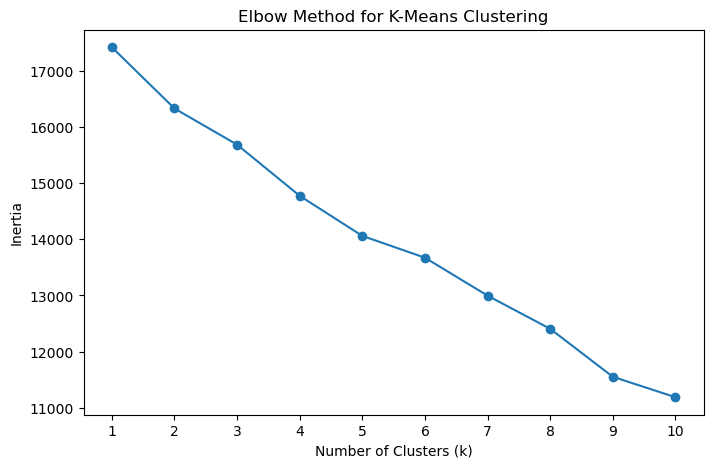

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means Clustering")
plt.xticks(K_range)
plt.show()

In [29]:
import warnings
warnings.filterwarnings("ignore")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
company_df["Cluster"] = kmeans.fit_predict(cluster_scaled)

print(company_df["Cluster"].value_counts().sort_index())

Cluster
0    109
1    146
2    171
3     71
4     31
Name: count, dtype: int64


In [30]:
cluster_summary = company_df.groupby("Cluster")[[
    "Yaşı",
    "Toplam Ücret",
    "TOPLAM KIDEM (AY)",
    "ÇALIŞTIĞI SÜRE AY",
    "ÇALIŞTIĞI SÜRE GÜN"
]].mean().round(2)

print(cluster_summary)

          Yaşı  Toplam Ücret  TOPLAM KIDEM (AY)  ÇALIŞTIĞI SÜRE AY  \
Cluster                                                              
0        31.49      27026.65              10.75               6.35   
1        21.32      25347.18               3.23               2.33   
2        26.21      24939.44               1.33               1.19   
3        19.10      23145.80               3.35               3.01   
4        23.10      24267.77               6.71               4.00   

         ÇALIŞTIĞI SÜRE GÜN  
Cluster                      
0                     13.18  
1                     12.39  
2                      9.93  
3                     13.17  
4                     14.06  


In [31]:
cluster_status = pd.crosstab(
    company_df["Cluster"],
    company_df["DURUM"]
)

print(cluster_status)

DURUM    Ayrıldı  Halen çalışmakta
Cluster                           
0             41                68
1            112                34
2            166                 5
3             54                17
4             21                10


In [32]:
cluster_status_percent = pd.crosstab(
    company_df["Cluster"],
    company_df["DURUM"],
    normalize="index"
) * 100

cluster_status_percent = cluster_status_percent.round(2)

print(cluster_status_percent)

DURUM    Ayrıldı  Halen çalışmakta
Cluster                           
0          37.61             62.39
1          76.71             23.29
2          97.08              2.92
3          76.06             23.94
4          67.74             32.26


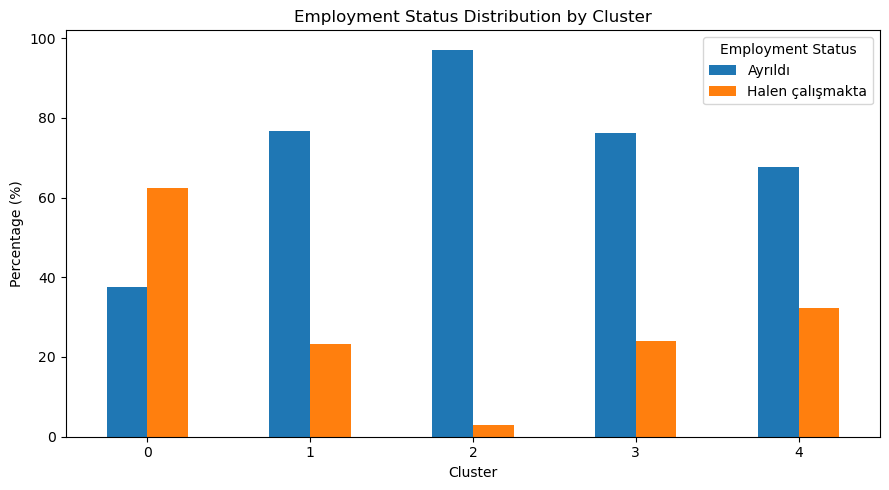

In [33]:
cluster_status_percent.plot(kind="bar", figsize=(9, 5))

plt.title("Employment Status Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Employment Status")
plt.tight_layout()
plt.show()